In [ ]:
import pandas as pd
#Gestión de bases de datos
import numpy as np
#Calculos matematicos, matrices, vectores
import matplotlib.pyplot as plt
import seaborn as sns
#Generación de gráficos

from sklearn.model_selection import train_test_split
#Partición de la muestra
from sklearn.linear_model import LogisticRegression
#Modelamiento mediante regresión logística
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
#Metricas del modelo que que permiten saber si es o no un buen modelo.

In [7]:
#Creamos un dataset simulado
np.random.seed(50)# reproductividad de un proyecto

n = 500#tamaño de la muestra
#Variables
edad = np.random.randint(18, 65, n)
ingresos = np.random.randint(1000000, 10000000, n)
deuda = np.random.randint(0, 8000000, n)
score_crediticio = np.random.randint(300, 850, n)
prestamos = np.random.randint(0, 6, n)

# Regla simple para mora
mora = (
    (deuda > ingresos * 0.7) &
    (score_crediticio < 550)
).astype(int)

df = pd.DataFrame({
    'edad': edad,
    'ingresos': ingresos,
    'deuda': deuda,
    'score_crediticio': score_crediticio,
    'prestamos': prestamos,
    'mora': mora
})

print(df.head())





   edad  ingresos    deuda  score_crediticio  prestamos  mora
0    50   7203494  5073823               818          0     0
1    29   6759146  4186248               584          2     0
2    63   4304746  6339370               440          5     1
3    51   3111078  5856970               560          2     0
4    48   4510436  5908050               802          4     0


In [12]:
#Revisamos la información de nuestro dataset
print(df.info())#Verificamos que cuenta con seis columnas (edad, ingresos, deuda,score_crediticio, prestamos, mora)
print(df.describe())
print(df['mora'].value_counts())#Podemos observar que 120 de la muestra de 500 clientes están en mora.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   edad              500 non-null    int32
 1   ingresos          500 non-null    int32
 2   deuda             500 non-null    int32
 3   score_crediticio  500 non-null    int32
 4   prestamos         500 non-null    int32
 5   mora              500 non-null    int32
dtypes: int32(6)
memory usage: 11.8 KB
None
             edad      ingresos         deuda  score_crediticio   prestamos  \
count  500.000000  5.000000e+02  5.000000e+02          500.0000  500.000000   
mean    40.848000  5.439104e+06  4.082950e+06          578.5460    2.540000   
std     14.381047  2.612964e+06  2.346581e+06          156.4976    1.704762   
min     18.000000  1.029314e+06  2.444000e+03          302.0000    0.000000   
25%     28.000000  3.150555e+06  2.050300e+06          436.0000    1.000000   
50%     42.000000 

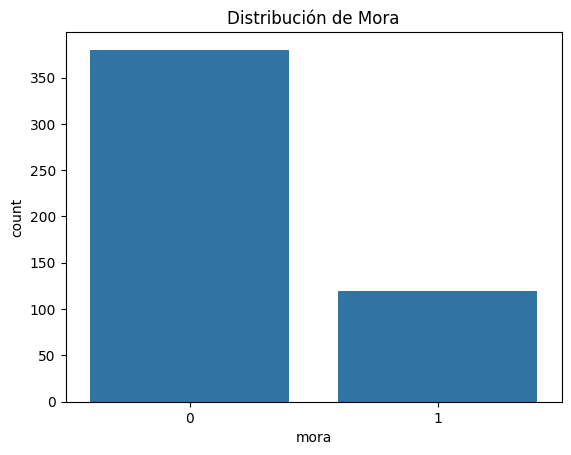

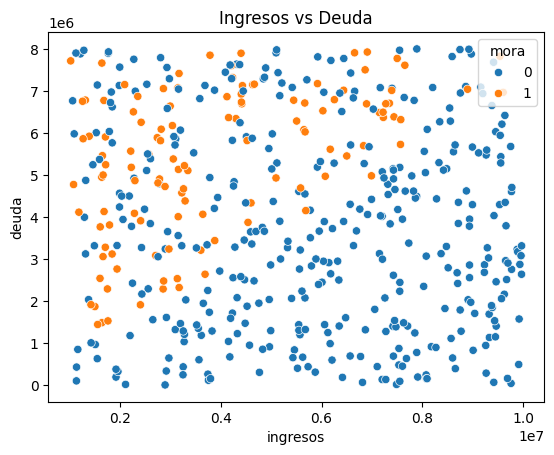

In [20]:
sns.countplot(x='mora', data=df)
plt.title('Distribución de Mora')
plt.show()
#Observamos la distribución de la variable mora. En este caos, la canidad de  clientes que estan en mora es menor a la cantidad de clientyes que no lo están.

sns.scatterplot(x='ingresos', y='deuda', hue='mora', data=df)
plt.title('Ingresos vs Deuda')
plt.show()
#Parece no haber relción al menos lineal entre la variable ingresos y deuda. Pero, los clientes que suelen tener ingresos bajos, suelen estar en mora.


In [22]:
#Definimos nuestra matriz de datos para  variables independientes.
X = df[['edad', 'ingresos', 'deuda',
        'score_crediticio', 'prestamos']]
#Definimos el vector de datos para la variable dependiente.
y = df['mora']


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,#20% de los datos serán para prueba. 80% para entrenamiento.
    random_state=42#reproducir resultados (tener siempre la misma partición)
)
#dividimos la muestra en grupos: entrenamiento y prueba.

In [ ]:
#Entrenamos el modelo. En este caso dado que neustra variable dependiente es una variable dicotomica, usamos regresión logística.


modelo = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'#Lo usamos cuando vemos datos debalanceados, pue ajusta automáticamente la importancia de cada clase en función de su frecuencia.
)

modelo.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [32]:
y_pred = modelo.predict(X_test)
#Calculo la prediciones a partir de modelo

In [33]:
accuracy = accuracy_score(y_test, y_pred)#El modelo tuvo una exactitud del 81% al clasificar clientes con y sin mora.

print("Accuracy:", accuracy)

Accuracy: 0.91


In [ ]:
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred))
#EL MODELO  INICIAL SIN "class_weight"class_weigth"ERA ADECUADO PARA DETECTAR CLIENTES QUE NO ESTAN EN MORA, PERO DEBE MEJORAR EN LA DTECCION DE CLIENTES EN MORA.
#Después de observar un desbalance en la variable objetivo, apliqué class_weight='balanced' en el modelo para darle mayor importancia a la clase minoritaria. Esto mejoró significativamente el recall de la clase de mora, pasando de un valor bajo a aproximadamente 0.90, reduciendo así los falsos negativos, que son críticos en un contexto financiero.


Reporte de clasificación:

              precision    recall  f1-score   support

           0       0.96      0.91      0.93        70
           1       0.82      0.90      0.86        30

    accuracy                           0.91       100
   macro avg       0.89      0.91      0.90       100
weighted avg       0.91      0.91      0.91       100



In [35]:
matriz = confusion_matrix(y_test, y_pred)
matriz

array([[64,  6],
       [ 3, 27]], dtype=int64)

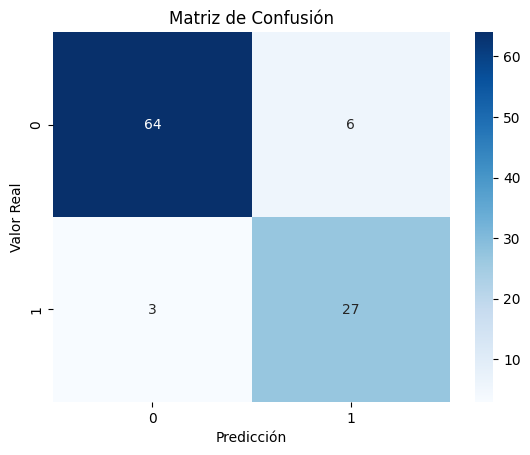

In [36]:
sns.heatmap(matriz,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()